## Preprocess the data

In [31]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated",
    category=FutureWarning)

warnings.filterwarnings(
    "ignore",
    message="The default of observed=False is deprecated",
    category=FutureWarning)

warnings.filterwarnings(
    "ignore",
    message="When grouping with a length-1 list-like",
    category=FutureWarning)

warnings.simplefilter(action='ignore', category=FutureWarning)

train = pd.read_csv('../Data/train.csv', index_col = 'id')
test = pd.read_csv('../Data/test.csv', index_col = 'id')
target = 'diagnosed_diabetes'

def overview(df, nunique_threshold=15):
    """
    Prints an overview of the DataFrame.
    - Ignores the last column (assumed target).
    - Counts numerical and categorical features.
    - Converts low-cardinality numeric features to categorical.
    """

    import pandas as pd

    # Drop last column (assumed target)
    features = df.iloc[:, :-1]

    # Initial type detection
    num_cols = features.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = features.select_dtypes(include=['object', 'category']).columns.tolist()

    # Convert low-cardinality numeric columns to categorical
    converted_cols = []
    for col in num_cols.copy():
        if features[col].nunique() <= nunique_threshold:
            df[col] = df[col].astype('category')
            num_cols.remove(col)
            cat_cols.append(col)
            converted_cols.append(col)

    print("===== DATA OVERVIEW =====")
    print(f"Total features (excluding last column): {features.shape[1]}")
    print(f"Numeric features: {len(num_cols)}")
    print(f"Categorical features: {len(cat_cols)}")

    if converted_cols:
        print(f"\nConverted to categorical (nunique ≤ {nunique_threshold}):")
        for col in converted_cols:
            print(f"  - {col}")

    print("\n--- Categorical Columns Detail ---")
    for col in cat_cols:
        print(f"{col}: {df[col].nunique()} unique values")

    return num_cols, cat_cols
    
num_cols, cat_cols = overview(train)

for col in train.select_dtypes(include='object').columns:
    train[col] = pd.Categorical(train[col])

for col in train.columns:
    if col in test.columns:
        test[col] = test[col].astype(train[col].dtype)

===== DATA OVERVIEW =====
Total features (excluding last column): 24
Numeric features: 14
Categorical features: 10

Converted to categorical (nunique ≤ 15):
  - alcohol_consumption_per_week
  - family_history_diabetes
  - hypertension_history
  - cardiovascular_history

--- Categorical Columns Detail ---
gender: 3 unique values
ethnicity: 5 unique values
education_level: 4 unique values
income_level: 5 unique values
smoking_status: 3 unique values
employment_status: 4 unique values
alcohol_consumption_per_week: 9 unique values
family_history_diabetes: 2 unique values
hypertension_history: 2 unique values
cardiovascular_history: 2 unique values


## Spliting model:

In [32]:
neg = np.sum(train[target] == 0)
pos = np.sum(train[target] == 1)
scale_pos_weight = neg / pos
scale_pos_weight
X = train.drop('diagnosed_diabetes',axis=1)
y = train['diagnosed_diabetes']

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc, roc_auc_score

X_train, X_val, y_train, y_val = train_test_split(X,y, stratify = y, random_state=42)

## XGBoost:

In [33]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score

dtrain_full = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dval_matrix = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)

xgb_params = {
    'objective': 'binary:logistic',
    'tree_method': 'hist',
    'booster': 'gbtree',
    'max_depth': 5,
    'eta': 0.07815109367099736,
    'subsample': 0.8712506708090506,
    'colsample_bytree': 0.7681646250943356,
    'gamma': 0.8918764623607585,
    'alpha': 4.470940159950184,
    'lambda': 4.022292589621206,
    'min_child_weight': 2,
    'max_cat_to_onehot': 7,
    'num_boost_round': 797,
    'scale_pos_weight': scale_pos_weight,  # keep your imbalance handling
    'enable_categorical': True,
    'n_jobs': -1,
    'eval_metric': 'auc', "seed": 42
}

num_boost_round = 977

xgb_model = xgb.train(
    params=xgb_params,
    dtrain=dtrain_full,
    num_boost_round=num_boost_round,
    evals=[(dtrain_full, "train"), (dval_matrix, "valid")],
    early_stopping_rounds=15,  # optional, stops if no improvement
    verbose_eval=50            # shows progress every 50 rounds
)

y_pred_xgb = xgb_model.predict(dval_matrix)
auc = roc_auc_score(y_val, y_pred_xgb)
print(f"Validation ROC-AUC XGBoost Model: {auc:.4f}")

[0]	train-auc:0.65958	valid-auc:0.65949
[50]	train-auc:0.71102	valid-auc:0.70940
[100]	train-auc:0.71648	valid-auc:0.71325
[150]	train-auc:0.72249	valid-auc:0.71763
[200]	train-auc:0.72649	valid-auc:0.72014
[250]	train-auc:0.72947	valid-auc:0.72175
[300]	train-auc:0.73205	valid-auc:0.72302
[350]	train-auc:0.73392	valid-auc:0.72372
[400]	train-auc:0.73581	valid-auc:0.72438
[450]	train-auc:0.73750	valid-auc:0.72489
[500]	train-auc:0.73902	valid-auc:0.72522
[550]	train-auc:0.74045	valid-auc:0.72555
[600]	train-auc:0.74192	valid-auc:0.72579
[643]	train-auc:0.74312	valid-auc:0.72591
Validation ROC-AUC XGBoost Model: 0.7259


## LightGBM

In [35]:
from lightgbm import LGBMClassifier, early_stopping
from sklearn.metrics import roc_auc_score

gbm_params = {
    'objective': 'binary',
    'boosting_type': 'gbdt',   # updated
    'num_leaves': 227,         # updated
    'max_depth': 11,
    'learning_rate': 0.015276056330994207,  # updated
    'min_child_samples': 61,   # updated
    'subsample': 0.6696617268568047,       # updated
    'colsample_bytree': 0.6678441905031072,  # updated
    'reg_alpha': 0.5113089859188895,      # updated
    'reg_lambda': 1.515216046045771,     # updated
    'scale_pos_weight': scale_pos_weight,   # keep your imbalance handling as requested
    'n_estimators': 353,      # from num_boost_round
    'n_jobs': -1
}

lightgbm_model = LGBMClassifier(**gbm_params,  verbosity=-1, random_state=42)

lightgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    categorical_feature=cat_cols,
    callbacks=[early_stopping(stopping_rounds=50, verbose=True)])

y_pred_gbm = lightgbm_model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred_gbm)
print(f"Final Validation ROC-AUC LightGBM: {auc:.6f}")

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[353]	valid_0's auc: 0.724026	valid_0's binary_logloss: 0.611013
Final Validation ROC-AUC LightGBM: 0.724026


## Catboost:

In [37]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

cat_params = {
    'iterations': 1162,                    # updated
    'depth': 7,                           # updated
    'learning_rate': 0.07750133623087592, # updated
    'l2_leaf_reg': 6.040419312733866,    # updated
    'bagging_temperature': 0.5698939842266584, # updated
    'border_count': 177,                   # updated
    'verbose': 0
}

# Identify categorical columns

cat_model = CatBoostClassifier(**cat_params, eval_metric="AUC", random_seed=42,
                               loss_function='Logloss')

cat_model.fit(
    X_train, y_train,
    cat_features=cat_cols,
    eval_set=(X_val, y_val),
    use_best_model=True, early_stopping_rounds=50)

y_pred_cat = cat_model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred_cat)
print(f"Final Validation ROC-AUC CatBoost: {auc:.6f}")

Final Validation ROC-AUC CatBoost: 0.725865


## Compare performance:
### 1. Confusion matrix

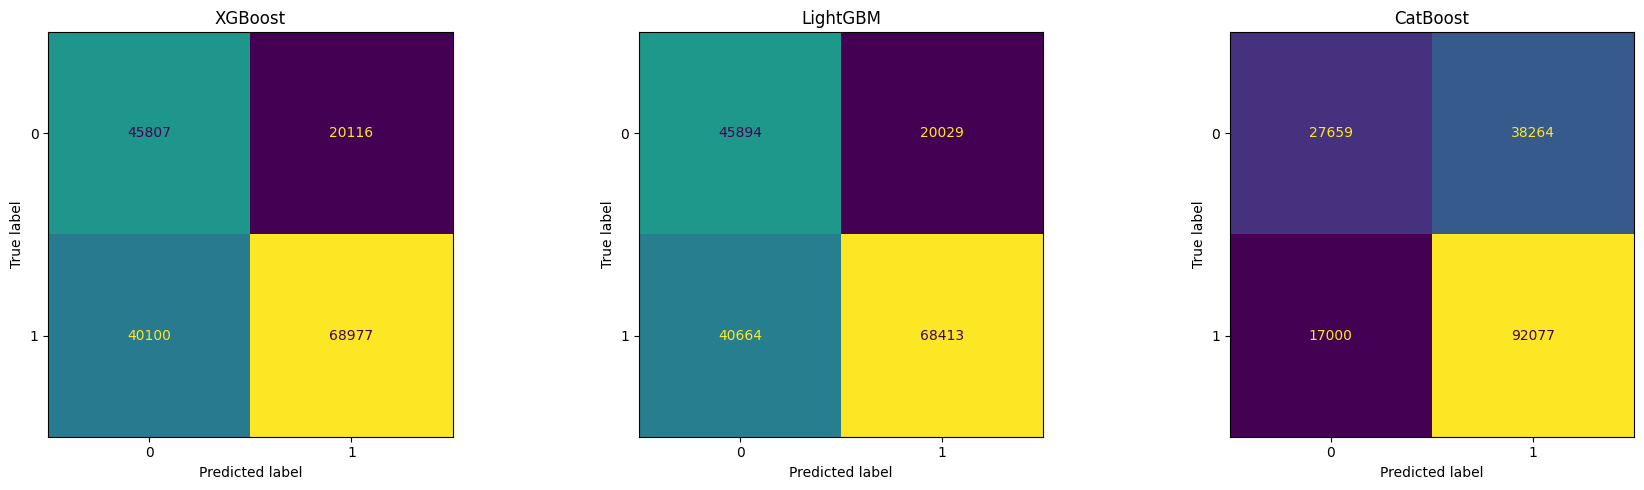

In [43]:
models = {
    "XGBoost": xgb_model,
    "LightGBM": lightgbm_model,
    "CatBoost": cat_model
}

y_val_pred_proba = {}
y_val_pred = {}

# Create DMatrix once for XGBoost
dval = xgb.DMatrix(X_val, enable_categorical=True)

for name, model in models.items():
    if name == "XGBoost":
        # Native Booster → predict returns probabilities directly
        y_val_pred_proba[name] = model.predict(dval)
    else:
        # sklearn-style models
        y_val_pred_proba[name] = model.predict_proba(X_val)[:, 1]

    y_val_pred[name] = (y_val_pred_proba[name] >= 0.5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, preds) in zip(axes, y_val_pred.items()):
    cm = confusion_matrix(y_val, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False, values_format='d')
    ax.set_title(name)

plt.tight_layout()
plt.show()

### 2. Classification Report:

In [44]:
for name in models.keys():
    print(f"\n{name} — Classification Report")
    print(classification_report(y_val, y_val_pred[name], digits=4))


XGBoost — Classification Report
              precision    recall  f1-score   support

         0.0     0.5332    0.6949    0.6034     65923
         1.0     0.7742    0.6324    0.6961    109077

    accuracy                         0.6559    175000
   macro avg     0.6537    0.6636    0.6498    175000
weighted avg     0.6834    0.6559    0.6612    175000


LightGBM — Classification Report
              precision    recall  f1-score   support

         0.0     0.5302    0.6962    0.6020     65923
         1.0     0.7735    0.6272    0.6927    109077

    accuracy                         0.6532    175000
   macro avg     0.6519    0.6617    0.6473    175000
weighted avg     0.6819    0.6532    0.6585    175000


CatBoost — Classification Report
              precision    recall  f1-score   support

         0.0     0.6193    0.4196    0.5002     65923
         1.0     0.7064    0.8441    0.7692    109077

    accuracy                         0.6842    175000
   macro avg     0.6629    

### 3. ROC curve Comparison:

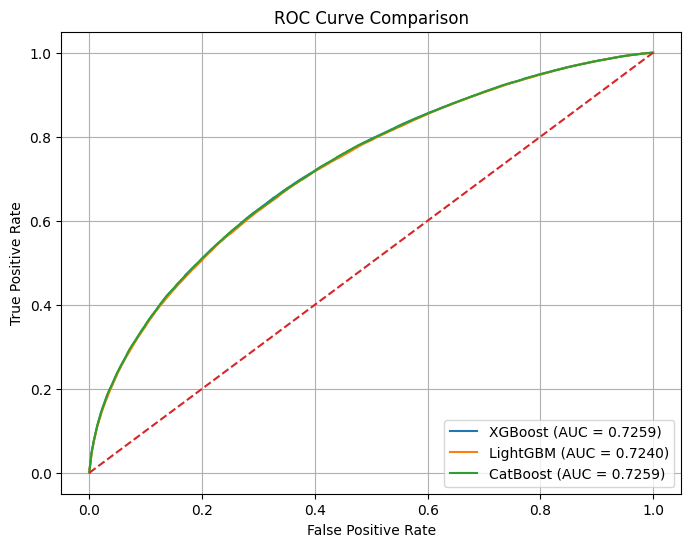

In [45]:
from sklearn.metrics import roc_curve, auc as sk_auc

plt.figure(figsize=(8, 6))

for name, probs in y_val_pred_proba.items():
    fpr, tpr, _ = roc_curve(y_val, probs)
    roc_auc = sk_auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### 4. Feature Importance:

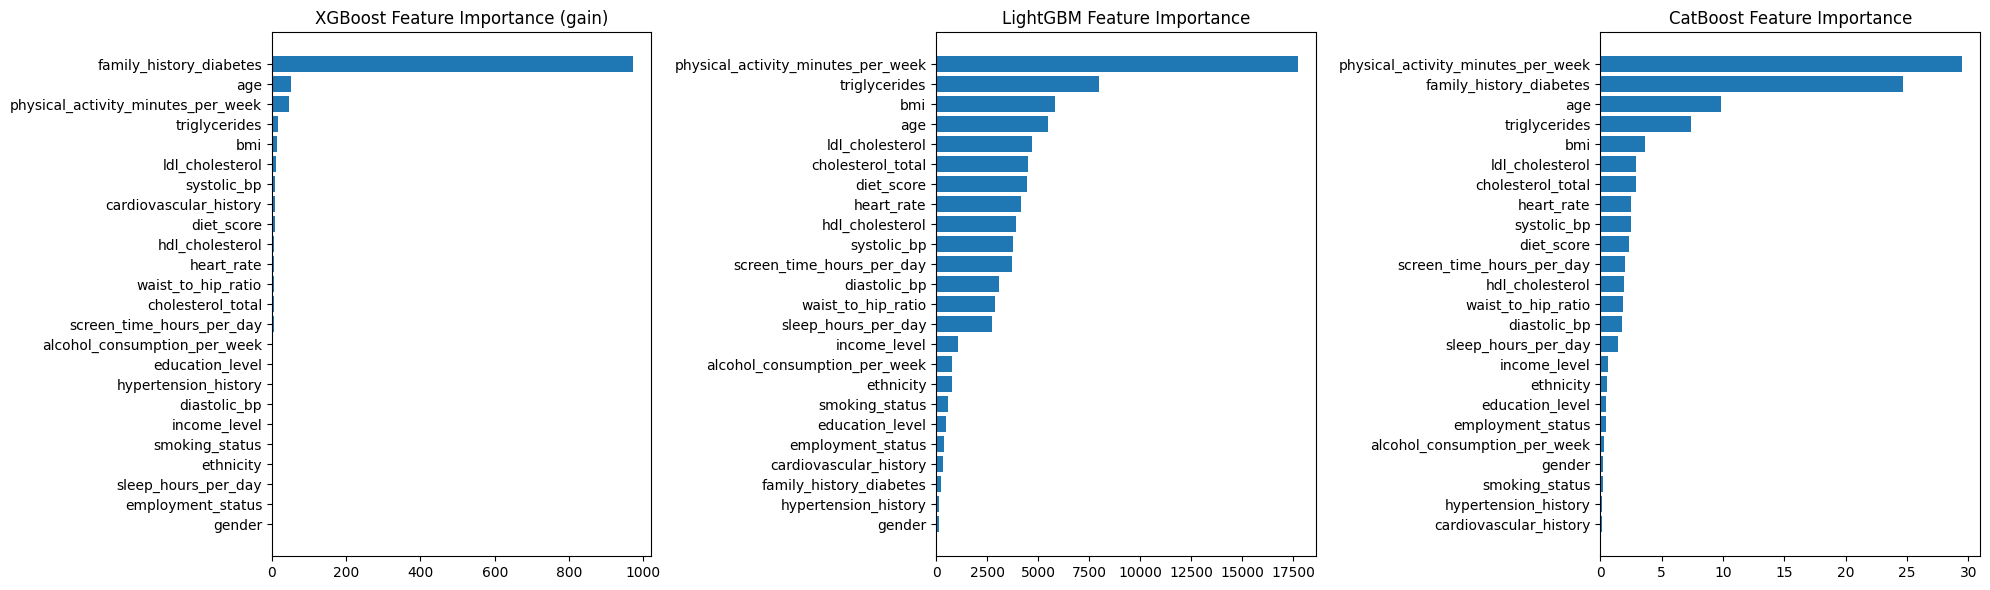

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

xgb_importance = xgb_model.get_score(importance_type="gain")

xgb_df = (
    pd.DataFrame({
        "feature": xgb_importance.keys(),
        "importance": xgb_importance.values()
    })
    .sort_values("importance", ascending=False)
    # .head(20)
)

axes[0].barh(xgb_df["feature"], xgb_df["importance"])
axes[0].set_title("XGBoost Feature Importance (gain)")
axes[0].invert_yaxis()
lgb_df = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": lightgbm_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
    # .head(20)
)

axes[1].barh(lgb_df["feature"], lgb_df["importance"])
axes[1].set_title("LightGBM Feature Importance")
axes[1].invert_yaxis()
cat_df = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": cat_model.get_feature_importance()
    })
    .sort_values("importance", ascending=False)
    # .head(20)
)

axes[2].barh(cat_df["feature"], cat_df["importance"])
axes[2].set_title("CatBoost Feature Importance")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()


===== Fold 1/5 =====
XGBoost Fold AUC: 0.72626 | Best iteration: 766
LightGBM Fold AUC: 0.72410 | Best iteration: 352
CatBoost Fold AUC: 0.72531 | Best iteration: 1133

===== Fold 2/5 =====
XGBoost Fold AUC: 0.72595 | Best iteration: 884
LightGBM Fold AUC: 0.72468 | Best iteration: 353
CatBoost Fold AUC: 0.72613 | Best iteration: 1159

===== Fold 3/5 =====
XGBoost Fold AUC: 0.72525 | Best iteration: 682
LightGBM Fold AUC: 0.72300 | Best iteration: 352
CatBoost Fold AUC: 0.72471 | Best iteration: 1134

===== Fold 4/5 =====
XGBoost Fold AUC: 0.72579 | Best iteration: 948
LightGBM Fold AUC: 0.72347 | Best iteration: 353
CatBoost Fold AUC: 0.72465 | Best iteration: 1130

===== Fold 5/5 =====
XGBoost Fold AUC: 0.72754 | Best iteration: 835
LightGBM Fold AUC: 0.72607 | Best iteration: 353
CatBoost Fold AUC: 0.72741 | Best iteration: 1119


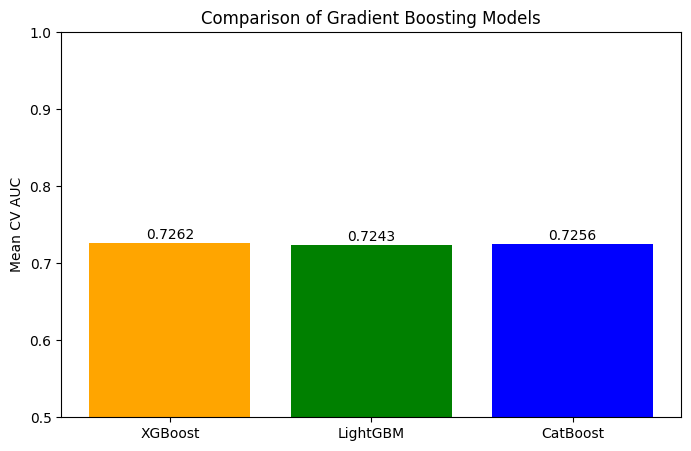

In [48]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
from lightgbm import LGBMClassifier, early_stopping
from catboost import CatBoostClassifier

# Define CV
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Prepare OOF storage
oof_preds = {}
oof_scores = {}
models = ["XGBoost", "LightGBM", "CatBoost"]

for model_name in models:
    oof_preds[model_name] = np.zeros(len(X_train))
    oof_scores[model_name] = []

# CV loop
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    print(f"\n===== Fold {fold}/{n_splits} =====")
    X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # XGBoost
    dtrain = xgb.DMatrix(X_tr, label=y_tr, enable_categorical=True)
    dval = xgb.DMatrix(X_va, label=y_va, enable_categorical=True)
    xgb_model_cv = xgb.train(
        params=xgb_params,
        dtrain=dtrain,
        num_boost_round=5000,
        evals=[(dval, "val")],
        early_stopping_rounds=50,
        verbose_eval=False
    )
    preds = xgb_model_cv.predict(dval)
    auc = roc_auc_score(y_va, preds)
    oof_preds["XGBoost"][val_idx] = preds
    oof_scores["XGBoost"].append(auc)
    print(f"XGBoost Fold AUC: {auc:.5f} | Best iteration: {xgb_model_cv.best_iteration}")

    # LightGBM
    lgbm_model_cv = LGBMClassifier(
        **gbm_params)
    lgbm_model_cv.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="auc",
        categorical_feature=cat_cols,
        callbacks=[early_stopping(50, verbose=False)]
    )
    preds = lgbm_model_cv.predict_proba(X_va)[:, 1]
    auc = roc_auc_score(y_va, preds)
    oof_preds["LightGBM"][val_idx] = preds
    oof_scores["LightGBM"].append(auc)
    print(f"LightGBM Fold AUC: {auc:.5f} | Best iteration: {lgbm_model_cv.best_iteration_}")

    # CatBoost
    cat_model_cv = CatBoostClassifier(**cat_params)
    cat_model_cv.fit(
        X_tr, y_tr,
        eval_set=(X_va, y_va),
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=50
    )
    preds = cat_model_cv.predict_proba(X_va)[:, 1]
    auc = roc_auc_score(y_va, preds)
    oof_preds["CatBoost"][val_idx] = preds
    oof_scores["CatBoost"].append(auc)
    print(f"CatBoost Fold AUC: {auc:.5f} | Best iteration: {cat_model_cv.get_best_iteration()}")

# Plot average CV AUC for each model
avg_auc = [np.mean(oof_scores[m]) for m in models]

plt.figure(figsize=(8, 5))
plt.bar(models, avg_auc, color=["orange", "green", "blue"])
plt.ylabel("Mean CV AUC")
plt.title("Comparison of Gradient Boosting Models")
plt.ylim(0.5, 1)
for i, v in enumerate(avg_auc):
    plt.text(i, v + 0.005, f"{v:.4f}", ha="center")
plt.show()

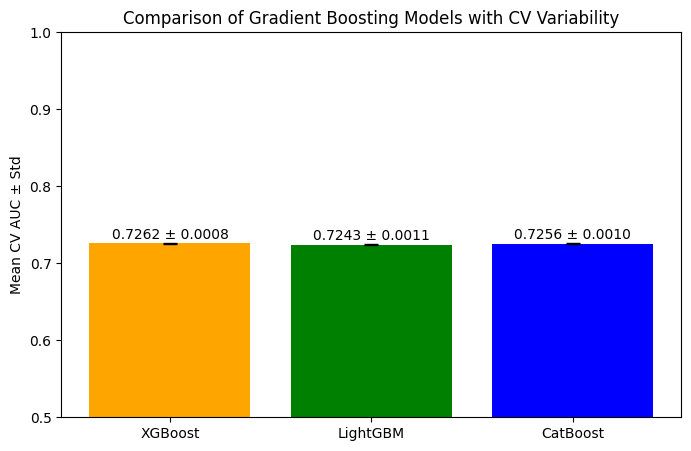

In [ ]:
# Calculate mean and std AUC for each model
mean_auc = [np.mean(oof_scores[m]) for m in models]
std_auc = [np.std(oof_scores[m]) for m in models]

# Plot average CV AUC with error bars
plt.figure(figsize=(8, 5))
plt.bar(models, mean_auc, yerr=std_auc, color=["orange", "green", "blue"], capsize=5)
plt.ylabel("Mean CV AUC ± Std")
plt.title("Comparison of Gradient Boosting Models with CV Variability")
plt.ylim(0.5, 1)
for i, (mean, std) in enumerate(zip(mean_auc, std_auc)):
    plt.text(i, mean + std + 0.005, f"{mean:.4f} ± {std:.4f}", ha="center")
plt.show()

Based on the comparision between those 3 models
# => XGBoost as my final model